# Práctica — Data Warehouse en Python y SQLite

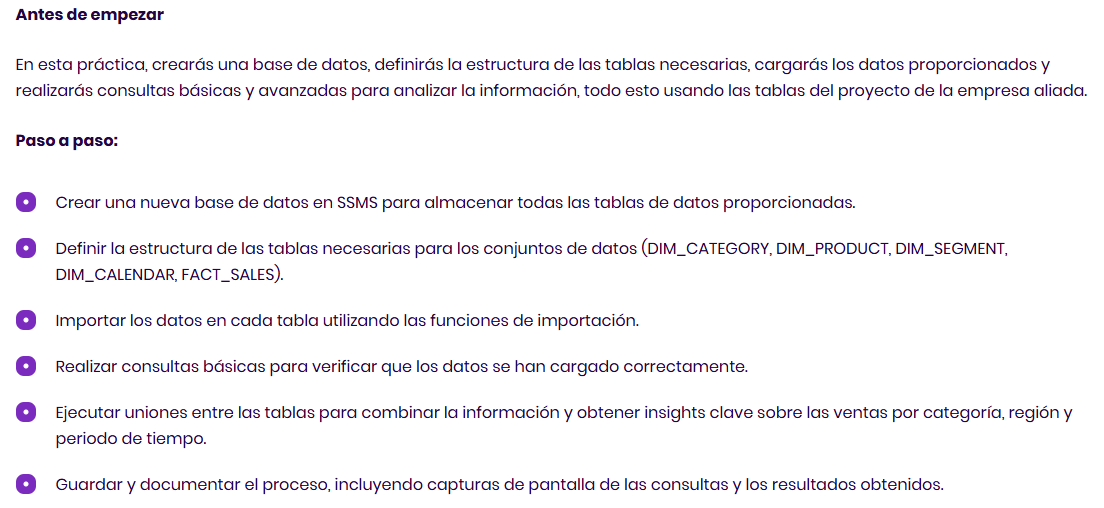

## 1. Crear la base de datos

In [1]:
import sqlite3
import pandas as pd
import os

# Crea el archivo Proyecto_Ventas.db si no existe
os.chdir("C:/Users/LUIS HERNANDEZ/Desktop/EBAC")
conn = sqlite3.connect("C:/Users/LUIS HERNANDEZ/Desktop/EBAC/Proyecto_Ventas.db")
cur = conn.cursor()
print("Base de datos Proyecto_Ventas.db lista.")

Base de datos Proyecto_Ventas.db lista.


## 2. Definir la estructura de las tablas

In [2]:
# Se elimina cada tabla si ya existía, para poder re-ejecutar el notebook
for t in ["FACT_SALES","DIM_PRODUCT","DIM_SEGMENT","DIM_CALENDAR","DIM_CATEGORY"]:
    cur.execute(f"DROP TABLE IF EXISTS {t};")

cur.execute("""
CREATE TABLE DIM_CATEGORY (
    ID_CATEGORY INTEGER PRIMARY KEY,
    CATEGORY    TEXT
);""")

cur.execute("""
CREATE TABLE DIM_CALENDAR (
    WEEK        TEXT PRIMARY KEY,
    YEAR        INTEGER,
    MONTH       INTEGER,
    WEEK_NUMBER INTEGER,
    DATE        TEXT
);""")

cur.execute("""
CREATE TABLE DIM_PRODUCT (
    MANUFACTURER     TEXT,
    BRAND            TEXT,
    ITEM             TEXT,
    ITEM_DESCRIPTION TEXT,
    CATEGORY         INTEGER,
    FORMAT           TEXT,
    ATTR1            TEXT,
    ATTR2            TEXT,
    ATTR3            TEXT
);""")

cur.execute("""
CREATE TABLE DIM_SEGMENT (
    CATEGORY INTEGER,
    ATTR1    TEXT,
    ATTR2    TEXT,
    ATTR3    TEXT,
    FORMAT   TEXT,
    SEGMENT  TEXT
);""")

cur.execute("""
CREATE TABLE FACT_SALES (
    WEEK                        TEXT,
    ITEM_CODE                   TEXT,
    TOTAL_UNIT_SALES            REAL,
    TOTAL_VALUE_SALES           REAL,
    TOTAL_UNIT_AVG_WEEKLY_SALES REAL,
    REGION                      TEXT
);""")

conn.commit()
print("5 tablas creadas.")

5 tablas creadas.


## 3. Importar los datos

Se leen los archivos con `pandas` (que maneja tanto `.csv` como `.xlsx`) y se cargan en su tabla con `to_sql(..., if_exists="append")`. A la categoría se le quitan los espacios sobrantes del texto.

In [3]:
# Leer cada archivo con la función adecuada
dim_category = pd.read_csv("DIM_CATEGORY.csv")
dim_segment  = pd.read_excel("DIM_SEGMENT.xlsx")
dim_calendar = pd.read_excel("DIM_CALENDAR (4).xlsx")
dim_product  = pd.read_excel("DIM_PRODUCT.xlsx")
fact_sales   = pd.read_csv("FACT_SALES.csv")

# Limpieza: quitar espacios/saltos de línea sobrantes en el nombre de categoría
dim_category["CATEGORY"] = dim_category["CATEGORY"].str.strip()


# Insertar en cada tabla
dim_category.to_sql("DIM_CATEGORY", conn, if_exists="append", index=False)
dim_calendar.to_sql("DIM_CALENDAR", conn, if_exists="append", index=False)
dim_product.to_sql("DIM_PRODUCT",  conn, if_exists="append", index=False)
dim_segment.to_sql("DIM_SEGMENT",  conn, if_exists="append", index=False)
fact_sales.to_sql("FACT_SALES",    conn, if_exists="append", index=False)
conn.commit()
print("Datos importados en las 5 tablas.")

Datos importados en las 5 tablas.


## 4. Consultas básicas de verificación

In [4]:
# Conteo de filas por tabla
consulta = """
SELECT 'DIM_CATEGORY' AS Tabla, COUNT(*) AS Filas FROM DIM_CATEGORY
UNION ALL SELECT 'DIM_CALENDAR', COUNT(*) FROM DIM_CALENDAR
UNION ALL SELECT 'DIM_PRODUCT',  COUNT(*) FROM DIM_PRODUCT
UNION ALL SELECT 'DIM_SEGMENT',  COUNT(*) FROM DIM_SEGMENT
UNION ALL SELECT 'FACT_SALES',   COUNT(*) FROM FACT_SALES;
"""
pd.read_sql(consulta, conn)

,Tabla,Filas
0,DIM_CATEGORY,5
1,DIM_CALENDAR,156
2,DIM_PRODUCT,505
3,DIM_SEGMENT,53
4,FACT_SALES,122002


In [5]:
# Vistazo a las primeras filas de la tabla de hechos
pd.read_sql("SELECT * FROM FACT_SALES LIMIT 5;", conn)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


In [6]:
# Vistazo a los productos
pd.read_sql("SELECT * FROM DIM_PRODUCT LIMIT 5;", conn)

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 0000075000592,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 0000075000608,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 0000075000615,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 0000075000622,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 0000075000639,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


## 5. Uniones (JOINs) para obtener insights

### 5.1 Ventas por categoría

In [7]:
# Nota: filtro por REGION LIKE "%AREA%" para usar solo las 6 areas y NO sumar tambien
# TOTAL AUTOS SCANNING MEXICO (el total nacional), que duplicaria las cifras.
pd.read_sql("""
    SELECT c.CATEGORY AS Categoria,
           ROUND(SUM(f.TOTAL_VALUE_SALES), 2) AS Valor_Total,
           ROUND(SUM(f.TOTAL_UNIT_SALES), 2)  AS Unidades_Total
    FROM FACT_SALES  f
    JOIN DIM_PRODUCT  p ON f.ITEM_CODE = p.ITEM
    JOIN DIM_CATEGORY c ON p.CATEGORY  = c.ID_CATEGORY
    WHERE f.REGION LIKE '%AREA%'
    GROUP BY c.CATEGORY
    ORDER BY Valor_Total DESC;
""", conn)

,Categoria,Valor_Total,Unidades_Total
0,FABRIC TREATMENT and SANIT,5521430.57,195880.17


### 5.2 Ventas por región

In [8]:
# Muestro solo las 6 areas (excluyo SCANNING MEXICO, que es el total nacional)
pd.read_sql("""
    SELECT REGION,
           ROUND(SUM(TOTAL_VALUE_SALES), 2) AS Valor_Total,
           ROUND(SUM(TOTAL_UNIT_SALES), 2)  AS Unidades_Total
    FROM FACT_SALES
    WHERE REGION LIKE '%AREA%'
    GROUP BY REGION
    ORDER BY Valor_Total DESC;
""", conn)

,REGION,Valor_Total,Unidades_Total
0,TOTAL AUTOS AREA 2,1188796.15,45319.92
1,TOTAL AUTOS AREA 5,1153335.54,36266.90
2,TOTAL AUTOS AREA 6,983957.57,38585.22
3,TOTAL AUTOS AREA 3,803655.34,25896.05
4,TOTAL AUTOS AREA 1,714249.98,25791.93
5,TOTAL AUTOS AREA 4,677436.00,24020.15


### 5.3 Ventas por periodo (año y mes)

In [9]:
pd.read_sql("""
    SELECT cal.YEAR AS Anio, cal.MONTH AS Mes,
           ROUND(SUM(f.TOTAL_VALUE_SALES), 2) AS Valor_Total
    FROM FACT_SALES  f
    JOIN DIM_CALENDAR cal ON f.WEEK = cal.WEEK
    WHERE f.REGION LIKE '%AREA%'
    GROUP BY cal.YEAR, cal.MONTH
    ORDER BY cal.YEAR, cal.MONTH;
""", conn)

,Anio,Mes,Valor_Total
0,2022,1,339220.41
1,2022,2,247267.67
2,2022,3,255026.22
3,2022,4,261002.16
4,2022,5,337474.82
5,2022,6,301900.05
6,2022,7,351031.23
7,2022,8,272720.57
8,2022,9,280613.10
9,2022,10,334475.58


### 5.4 Top 10 marcas por valor de ventas

In [10]:
pd.read_sql("""
    SELECT p.BRAND AS Marca,
           ROUND(SUM(f.TOTAL_VALUE_SALES), 2) AS Valor_Total
    FROM FACT_SALES  f
    JOIN DIM_PRODUCT p ON f.ITEM_CODE = p.ITEM
    WHERE f.REGION LIKE '%AREA%'
    GROUP BY p.BRAND
    ORDER BY Valor_Total DESC
    LIMIT 10;
""", conn)

,Marca,Valor_Total
0,CLORALEX,2696809.34
1,VANISH,1084144.86
2,CLOROX,685875.94
3,BLANCATEL,326242.02
4,OXI CLEAN,218485.40
5,DR.BECKMANN,139859.65
6,BANDERA,134968.52
7,LOS PATITOS,71372.85
8,CLARASOL,70506.10
9,LYSOL,35278.68


### 5.5 Ventas por segmento (usando la tabla puente DIM_SEGMENT)

In [11]:
pd.read_sql("""
    SELECT s.SEGMENT AS Segmento,
           ROUND(SUM(f.TOTAL_VALUE_SALES), 2) AS Valor_Total
    FROM FACT_SALES  f
    JOIN DIM_PRODUCT p ON f.ITEM_CODE = p.ITEM
    JOIN DIM_SEGMENT s
         ON p.CATEGORY = s.CATEGORY AND p.ATTR1 = s.ATTR1
        AND p.ATTR2 = s.ATTR2 AND p.ATTR3 = s.ATTR3 AND p.FORMAT = s.FORMAT
    WHERE f.REGION LIKE '%AREA%'
    GROUP BY s.SEGMENT
    ORDER BY Valor_Total DESC;
""", conn)

,Segmento,Valor_Total
0,BLEACH,3790642.19
1,LIQUID & GEL,727028.13
2,POWDER,517510.89
3,PRETREAT,316001.11
4,BAR,121769.67
5,SANITIZER,40957.87
6,OTHERS,7520.71


In [12]:
# Cerrar la conexión
conn.close()

## 6. Conclusiones

- La base `Proyecto_Ventas.db` se creo con las 5 tablas del esquema estrella y se cargaron correctamente (CATEGORY = 5, CALENDAR = 156, PRODUCT = 505, SEGMENT = 53, FACT_SALES = 122,002 filas).
- **Importante sobre las regiones:** la columna REGION trae las 6 areas y ademas TOTAL AUTOS SCANNING MEXICO, que es el **total nacional** (la suma de las 6 areas). Por eso en todas las consultas de totales filtro `WHERE REGION LIKE "%AREA%"`, para usar solo las 6 areas y no duplicar las cifras.
- **Por categoria:** las ventas corresponden a la categoria *FABRIC TREATMENT and SANIT*, con un valor total de ~5.52 millones (el total nacional correcto).
- **Por region:** las areas que mas venden son *AREA 2* y *AREA 5*, que juntas concentran mas del 42% del valor.
- **Top marcas:** *CLORALEX* es la marca lider por valor, seguida de *VANISH*; Lysol aparece mucho mas abajo.
- Estas cifras ya coinciden con las del dashboard de Power BI, que tambien usa solo las 6 areas.